Script Overview:
1. Uncertainty terms get counted for each NSI
2. The Uncertainty Counts are normalized
3. The NSI distributions are plotted

1. The Uncertainty terms are counted for each NSI

Australia:

In [1]:
import os
import spacy
from nltk.util import ngrams
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



nlp = spacy.load("en_core_web_sm")



uncertainty_terms = set([
    "always", "certain", "chance", "common", "doubtful", "expected","frequently","generally", "likely", 
    "impossible","never","inconclusive","often",
    "possible", "predicatable", "probable","rarely", "seldom", "slightly", "slight", "sometimes", 
    "uncertain", "uncommon","usually", "unlikely"
])


# tokenization fnc
excluded_tokens = set()
def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[6:]
        text = "".join(lines)

    doc = nlp(text)
    return doc


# uncertainty fnc
def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms


# Directory with files
  


def get_u_counts(directory):
    doc_u_counts = []
    filenames = []
    for file in os.listdir(directory):
        file_path = os.path.join(directory, file)
        doc = tokenize_text(file_path)

        found_terms = find_uncertainty_terms(doc)
        if found_terms:
            doc_u_counts.append(len(found_terms))
            filenames.append(file)
    return doc_u_counts, filenames    

In [2]:
directory = "Australia/filtered_a"
abs_counts, abs_filenames = get_u_counts(directory)

In [42]:
print(abs_counts)
sum(abs_counts)

[1, 24, 11, 1, 6, 2, 13, 10, 1, 7, 92, 3, 11, 5, 1, 6, 5, 1, 10, 2, 1, 37, 1, 9, 1, 4, 1, 13, 111, 2, 9, 7, 2, 5, 12, 11, 3, 2, 2, 8, 1, 1, 6, 22, 10, 5, 1, 1, 9, 2, 18, 3, 10, 3, 2, 9, 4, 2, 2, 2, 10, 17, 1, 2, 1, 10, 12, 2, 8, 7, 4, 1, 3, 6, 2, 5, 11, 68, 1, 11, 1, 3, 2, 2, 7, 15, 78, 4, 2, 11, 2, 1, 1, 2, 3, 1, 4, 20, 7, 1, 1, 2, 1, 6, 109, 8, 2, 9, 2, 9, 10, 4, 1, 1, 7, 6, 9, 14, 13, 3, 2, 2, 1, 24, 1, 20, 1, 5, 1, 17, 12, 12, 12, 11, 26, 3, 5, 12, 69, 1, 3, 13, 1, 7, 1, 11, 1, 15, 1, 2, 8, 7, 7, 114, 31, 5, 6, 9, 10, 11, 2, 7, 11, 9, 16, 3, 1, 10, 5, 10, 6, 6, 5, 4, 2, 20, 3, 10, 1]


1763

CBS

In [3]:
uncertainty_terms = set([
    "altijd", "kans", "meestal", "misschien", "mogelijk", "nooit", "onmogelijk", "onwaarschijnlijk", "onzeker", 
    "soms", "twijfelachtig", "vaak", "vermoedelijk","waarschijnlijk", "zeker", "zelden", "bijna",
])

def tokenize(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[4:]
        text = "".join(lines)
    doc = nlp(text)

    return(doc)

def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms


import os 
import spacy
nlp = spacy.load("nl_core_news_sm")

def get_u_counts(directory):
    doc_u_counts = []
    filenames = []
    for file in os.listdir(directory):
        file_path = os.path.join(directory, file)
        doc = tokenize(file_path)

        found_terms = find_uncertainty_terms(doc)
        if found_terms:
            doc_u_counts.append(len(found_terms))
            filenames.append(file)
    return doc_u_counts, filenames    

In [4]:
directory = "NL_GEN/filt_art"
cbs_counts, cbs_filenames = get_u_counts(directory)

In [53]:
sum(cbs_counts)

3101

StatCan

In [5]:
import os
import spacy
from nltk.util import ngrams
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



nlp = spacy.load("en_core_web_sm")


uncertainty_terms = set([
    "always", "certain", "chance", "common", "doubtful", "expected","frequently","generally", "likely", 
    "impossible","never","inconclusive","often",
    "possible", "predicatable", "probable","rarely", "seldom", "slightly", "slight", "sometimes", 
    "uncertain", "uncommon","usually", "unlikely"
])


# tokenization fnc
excluded_tokens = set()
def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[6:]
        text = "".join(lines)

    doc = nlp(text)
    return doc
    

def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms

def get_u_counts(directory):
    doc_u_counts = []
    filenames = []
    for file in os.listdir(directory):
        file_path = os.path.join(directory, file)
        doc = tokenize_text(file_path)

        found_terms = find_uncertainty_terms(doc)
        if found_terms:
            doc_u_counts.append(len(found_terms))
            filenames.append(file)
    return doc_u_counts, filenames   

In [6]:
directory = "Canada/scraped_a"
statcan_counts, statcan_filenames = get_u_counts(directory)

2. The Uncertainty Counts are normalized

In [ ]:
# normalization was done by lines
statcan_norm_counts = [count / len(open(os.path.join("Canada/scraped_a", file)).readlines()) for count, file in zip(statcan_counts, statcan_filenames)]
abs_norm_counts = [count / len(open(os.path.join("Australia/filtered_a", file)).readlines()) for count, file in zip(abs_counts, abs_filenames)]

# for cbs specified only count non empty lines
cbs_norm_counts = [
    count / len([line for line in open(os.path.join("NL_GEN/filt_art", file)).readlines()[6:] if line.strip() != ''])
    for count, file in zip(cbs_counts, cbs_filenames)
]

In [ ]:
# combine dataframe
statcan_df = pd.DataFrame({'uncertainty_count': statcan_norm_counts, 'NSI': ['StatCan'] * len(statcan_norm_counts)})
abs_df = pd.DataFrame({'uncertainty_count': abs_norm_counts, 'NSI': ['ABS'] * len(abs_norm_counts)})
cbs_df = pd.DataFrame({'uncertainty_count': cbs_norm_counts, 'NSI': ['CBS'] * len(cbs_norm_counts)})

# Combine all NSI DataFrames into one
all_data_df = pd.concat([statcan_df, abs_df, cbs_df])

# this is done so this can be used as a category for seaborn later
all_data_df["NSI"] = all_data_df["NSI"].astype("category")

3. The NSI distributions are plotted

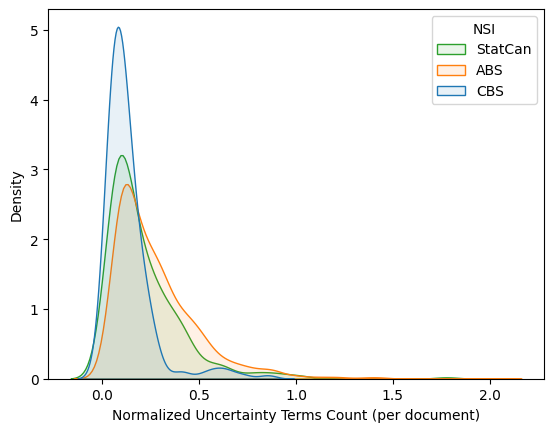

In [ ]:

plt.figure()
sns.kdeplot(data=all_data_df, x='uncertainty_count', hue='NSI', fill = True, common_norm=False, alpha = 0.1)
plt.xlabel('Normalized Uncertainty Terms Count (per document)')
plt.ylabel('Density')
plt.legend(title='NSI', labels = all_data_df["NSI"].unique())


plt.show()

Extra: Looking at Lengths

In [ ]:
# getting raw counts:
# for abs and statcan as their content starts on the same line
# Function to calculate document length (non-empty lines)
def get_doc_lengths(directory, filenames):
    doc_lengths = []
    for file in filenames:
        file_path = os.path.join(directory, file)
        with open(file_path, "r") as f:
            lines = f.readlines()[6:]  
            non_empty_lines = [line for line in lines if line.strip() != '']  # Exclude empty lines
            doc_lengths.append(len(non_empty_lines))  # Count non-empty lines
    return doc_lengths

# Get document lengths for each NSI (using non-empty lines)
statcan_doc_lengths = get_doc_lengths("Canada/scraped_a", statcan_filenames)
abs_doc_lengths = get_doc_lengths("Australia/filtered_a", abs_filenames)



Text(5.069444444444452, 0.5, 'Frequency')

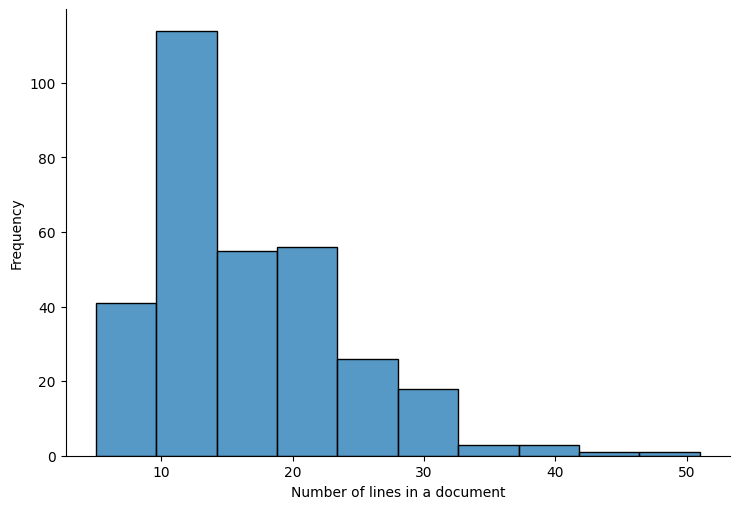

In [86]:
sns.displot(statcan_doc_lengths, bins = 10, aspect = 1.5)
plt.xlabel("Number of lines in a document")
plt.ylabel("Frequency")


In [83]:
min(statcan_doc_lengths)

5

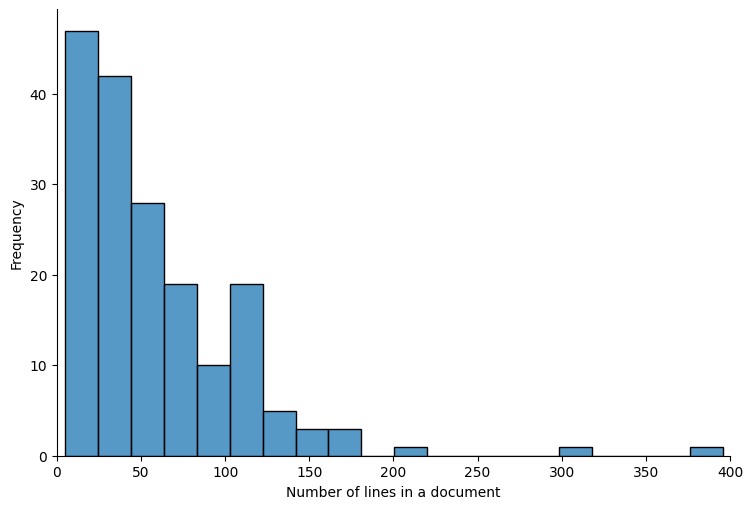

In [79]:
sns.displot(abs_doc_lengths, bins = 20, aspect = 1.5)
plt.xlabel("Number of lines in a document")
plt.ylabel("Frequency")
plt.xlim(0,400)

In [82]:
min(abs_doc_lengths)


5

Text(5.069444444444452, 0.5, 'Frequency')

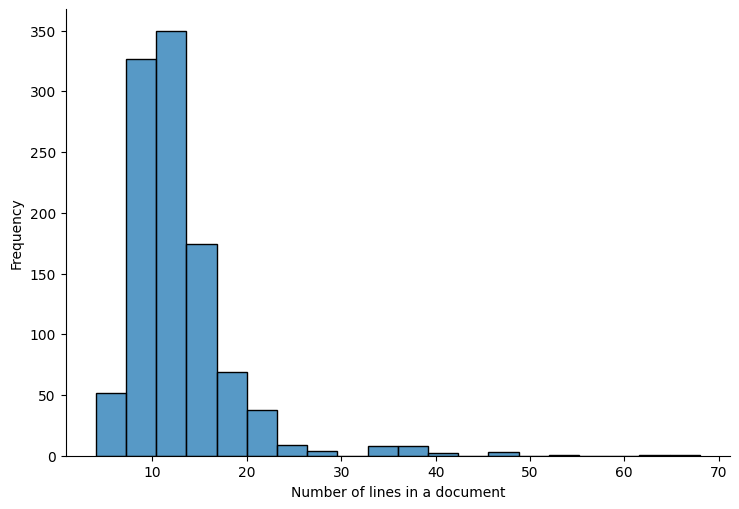

In [76]:
sns.displot(cbs_doc_lengths, bins = 20, aspect = 1.5)
plt.xlabel("Number of lines in a document")
plt.ylabel("Frequency")


In [ ]:
def get_doc_lengths(directory, filenames):
    doc_lengths = []
    for file in filenames:
        file_path = os.path.join(directory, file)
        with open(file_path, "r") as f:
            lines = f.readlines()[4:] 
            non_empty_lines = [line for line in lines if line.strip() != '']  # Exclude empty lines
            doc_lengths.append(len(non_empty_lines))  
    return doc_lengths
cbs_doc_lengths = get_doc_lengths("NL_GEN/filt_art", cbs_filenames)

<Figure size 1200x600 with 0 Axes>

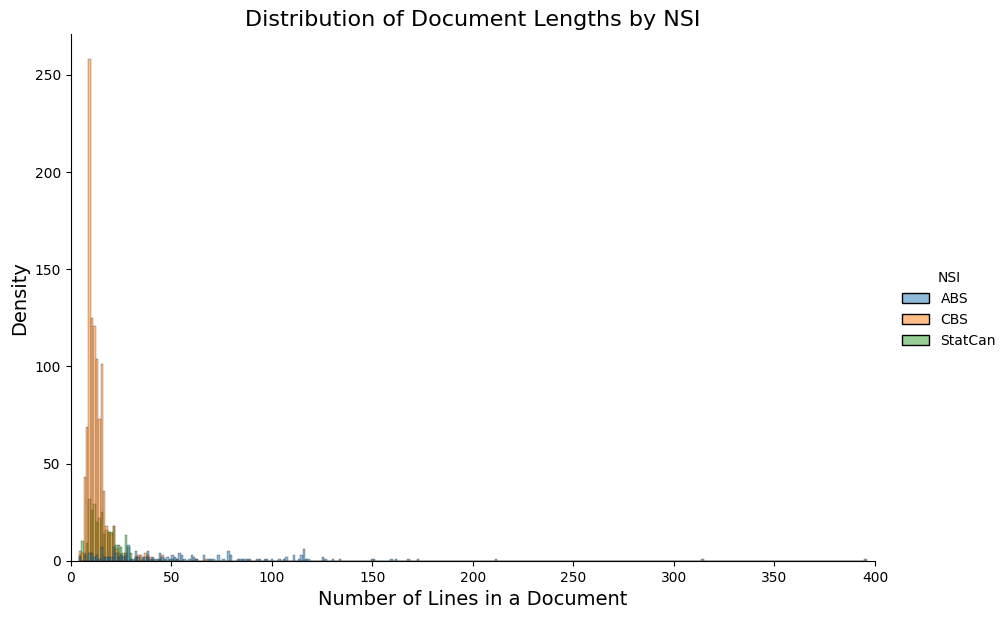

In [ ]:
## plotting doc length
statcan_doc_lengths = get_doc_lengths("Canada/scraped_a", statcan_filenames)
abs_doc_lengths = get_doc_lengths("Australia/filtered_a", abs_filenames)
cbs_doc_lengths = get_doc_lengths("NL_GEN/filt_art", cbs_filenames)

# Combine data into a single DataFrame for easier plotting
statcan_df = pd.DataFrame({'doc_length': statcan_doc_lengths, 'NSI': ['StatCan'] * len(statcan_doc_lengths)})
abs_df = pd.DataFrame({'doc_length': abs_doc_lengths, 'NSI': ['ABS'] * len(abs_doc_lengths)})
cbs_df = pd.DataFrame({'doc_length': cbs_doc_lengths, 'NSI': ['CBS'] * len(cbs_doc_lengths)})

# Combine all the data into one DataFrame
all_data_df = pd.concat([statcan_df, abs_df, cbs_df])
all_data_df["NSI"] = all_data_df["NSI"].astype("category")

# Plotting the distributions with sns.displot()
plt.figure(figsize=(12, 6))
sns.displot(all_data_df, x='doc_length', hue='NSI', height=6, aspect=1.5)

# labels and title
plt.title("Distribution of Document Lengths by NSI", fontsize=16)
plt.xlabel("Number of Lines in a Document", fontsize=14)
plt.ylabel("Density", fontsize=14)

plt.xlim(0, 400)  

plt.show()

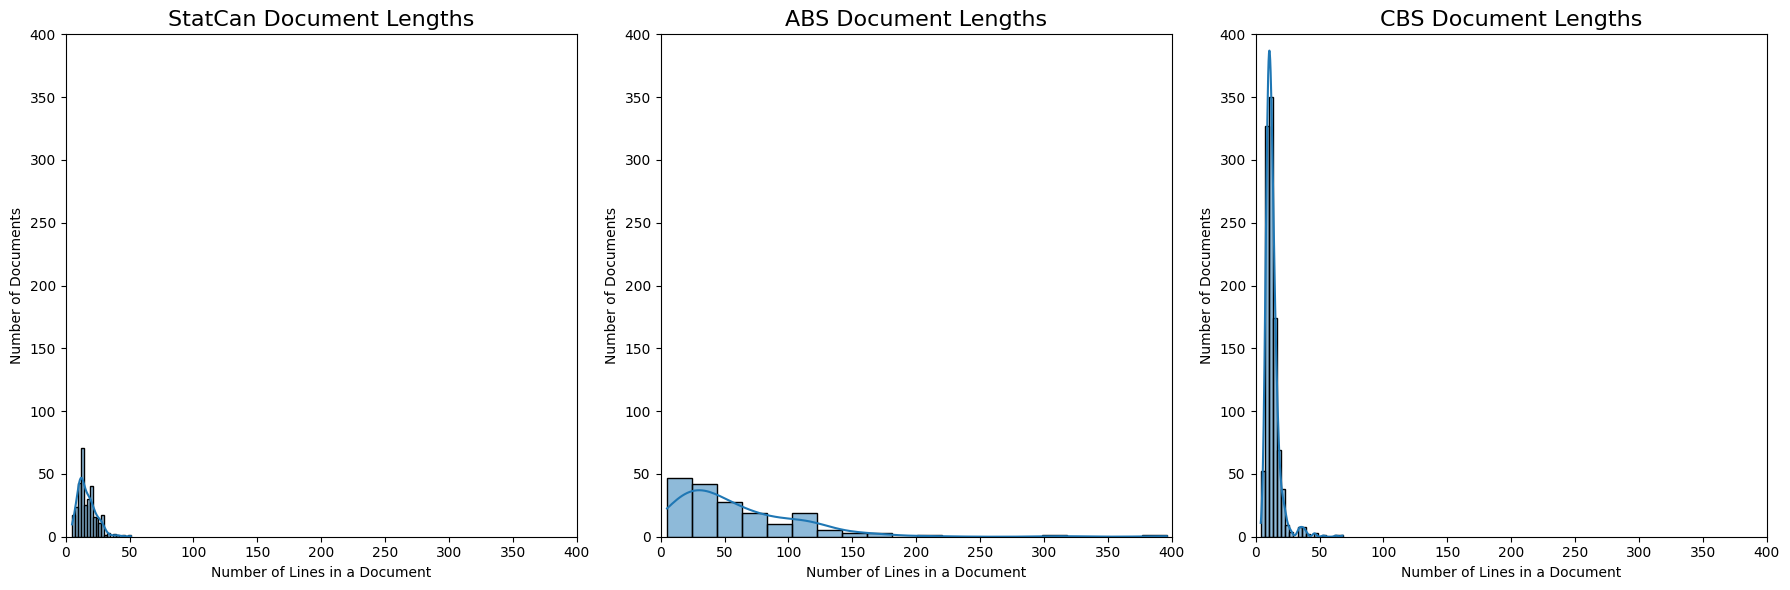

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



# Get document lengths for all three datasets
statcan_doc_lengths = get_doc_lengths("Canada/scraped_a", statcan_filenames)
abs_doc_lengths = get_doc_lengths("Australia/filtered_a", abs_filenames)
cbs_doc_lengths = get_doc_lengths("NL_GEN/filt_art", cbs_filenames)

# Create subplots ( 3 NSIs, 3 subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot for StatCan
sns.histplot(statcan_doc_lengths, kde=True, bins=20, ax=axes[0])
axes[0].set_title("StatCan Document Lengths", fontsize=16) 
axes[0].set_xlabel("Number of Lines in a Document")
axes[0].set_ylabel("Number of Documents")  
axes[0].set_xlim(0, 400) 
axes[0].set_ylim(0, 400)  

# Plot for ABS
sns.histplot(abs_doc_lengths, kde=True, bins=20, ax=axes[1])
axes[1].set_title("ABS Document Lengths", fontsize=16)  
axes[1].set_xlabel("Number of Lines in a Document")
axes[1].set_ylabel("Number of Documents")  
axes[1].set_xlim(0, 400)  
axes[1].set_ylim(0, 400)  

# Plot for CBS
sns.histplot(cbs_doc_lengths, kde=True, bins=20, ax=axes[2])
axes[2].set_title("CBS Document Lengths", fontsize=16)  
axes[2].set_xlabel("Number of Lines in a Document")
axes[2].set_ylabel("Number of Documents")  
axes[2].set_xlim(0, 400)  
axes[2].set_ylim(0, 400)  


plt.tight_layout()


plt.show()
